# Configuration

In [99]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import pandas as pd
from jiwer import process_words, process_characters, wer

In [100]:
# ===== CONFIG =====
PREDICTIONS_DIR = Path("../data/processed/asr_predictions/")

# Explicit list of prediction files to load (relative to PREDICTIONS_DIR).
# Add or remove filenames to control which models are included in the analysis.
PREDICTION_FILES = [
    "canary_nvidia_canary-1b-v2_predictions.jsonl",
    #"conformer_ctc_stt_en_conformer_ctc_large_predictions.jsonl",
    #"speechbrain_speechbrain_asr-crdnn-rnnlm-librispeech_predictions.jsonl",
    #"wav2vec2_facebook_wav2vec2-large-960h-lv60-self_predictions.jsonl",
    #"whisper_tiny_word_timestamps_predictions.jsonl",
    #"whisper_base_word_timestamps_predictions.jsonl",
    #"whisper_small_word_timestamps_predictions.jsonl",
    "whisper_medium_word_timestamps_predictions.jsonl",
    "whisper_large-v3_word_timestamps_predictions.jsonl",
]

# Map raw model IDs to readable display names
CLEAN_NAMES = {
    "canary:nvidia/canary-1b-v2":                          "Canary 1B",
    "conformer_ctc:stt_en_conformer_ctc_large":            "Conformer-CTC (Large)",
    "speechbrain:speechbrain/asr-crdnn-rnnlm-librispeech": "SpeechBrain CRDNN",
    "wav2vec2:facebook/wav2vec2-large-960h-lv60-self":     "Wav2Vec2 Large",
    "whisper:tiny":                                         "Whisper Tiny",
    "whisper:base":                                         "Whisper Base",
    "whisper:small":                                        "Whisper Small",
    "whisper:medium":                                       "Whisper Medium",
    "whisper:large-v3":                                     "Whisper Large v3",
    "whisperx:small":                                       "WhisperX Small",
}

# Filler words stripped in the "filtered" metric variant.
# AMI meeting speech has high filler-word rates; filtering gives a fairer cross-model comparison.
FILLER_WORDS = {
    "uh", "um", "mm", "hmm", "hm", "mhm", "mmhm", "mmhmm",
    "ah", "eh", "er", "erm", "huh", "uhu", "uhuh", "mmm"
}

# Minimum reference length (chars) — very short utterances are unreliable for WER
# Set to 0 to evaluate all segments
MIN_REF_CHARS = 0

# Latency outlier removal
WARMUP_DROP = 5          # rows to skip per model (cold-start / JIT warm-up effects)
OUTLIER_PERCENTILE = 98  # clip the top X% to remove server contention spikes

# Metrics to compute — remove any entry to skip it entirely.
# "wer", "mer", "wil" share one alignment pass; "cer" adds a second character-level pass.
METRICS = ["wer", "mer", "wil"]

In [101]:
# =========================
# HELPERS
# =========================
def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        for line in f:
            rows.append(json.loads(line))
    return pd.DataFrame(rows)


def detect_timestamp_mode(df, file_path=None):
    # Content-based detection: word_timestamps column present and populated
    if "word_timestamps" in df.columns:
        if df["word_timestamps"].apply(lambda x: isinstance(x, list)).any():
            return "timestamps"
    # Filename fallback
    if file_path is not None:
        if "timestamp" in Path(file_path).stem.lower():
            return "timestamps"
    return "no_timestamps"


def load_all_predictions(folder, files):
    dfs = []
    for filename in files:
        file = Path(folder) / filename
        df = load_jsonl(file)
        if "model" not in df.columns:
            df["model"] = file.stem
        ts_mode = detect_timestamp_mode(df, file)
        df["timestamp_mode"] = ts_mode
        # Combined label used for grouping throughout the notebook
        df["model_variant"] = df["model"] + " | " + ts_mode
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)


def filter_fillers(text):
    text = str(text).lower()
    text = text.replace("-", " ").replace("_", " ")  # hyphens and AMI letter-spelling (B_R_E_)
    text = re.sub(r"[^\w\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return " ".join(w for w in text.split() if w not in FILLER_WORDS)

# Data Loading

In [102]:
# =========================
# LOAD
# =========================
df_raw = load_all_predictions(PREDICTIONS_DIR, PREDICTION_FILES)
df_raw[["model", "timestamp_mode", "model_variant"]].drop_duplicates().sort_values(["model", "timestamp_mode"])

,model,timestamp_mode,model_variant
0,canary:nvidia/canary-1b-v2,no_timestamps,canary:nvidia/canary-1b-v2 | no_timestamps
40000,whisper:large-v3,timestamps,whisper:large-v3 | timestamps
20000,whisper:medium,timestamps,whisper:medium | timestamps


# Preprocessing

In [103]:
# =========================
# FILTER — keep only segments present across ALL model variants
# Ensures a fair comparison: every model is evaluated on the same set
# =========================
df = df_raw.copy()
df["ref_num_chars"] = df["reference_text"].astype(str).str.len()

# Apply minimum reference length filter
if MIN_REF_CHARS > 0:
    df = df[df["ref_num_chars"] >= MIN_REF_CHARS].copy()

n_variants = df["model_variant"].nunique()
common_segments = (
    df.groupby("segment_id")["model_variant"]
      .nunique()
      .loc[lambda x: x == n_variants]
      .index
)
df = df[df["segment_id"].isin(common_segments)].copy()
print(f"Segments kept: {df['segment_id'].nunique()} (MIN_REF_CHARS={MIN_REF_CHARS})")

# Prepare text columns — raw and filler-stripped variants
df["ref_raw"]      = df["reference_text"].astype(str)
df["hyp_raw"]      = df["asr_text"].astype(str)
df["ref_filtered"] = df["reference_text"].apply(filter_fillers)
df["hyp_filtered"] = df["asr_text"].apply(filter_fillers)

# Remove rows where both ref and hyp collapse to empty after filler stripping
df_eval = df[~((df["ref_filtered"] == "") & (df["hyp_filtered"] == ""))].copy()
print(f"Rows after filler-empty removal: {len(df_eval)}")

Segments kept: 20000 (MIN_REF_CHARS=0)
Rows after filler-empty removal: 57245


In [104]:
# =========================
# LATENCY — trim warmup rows and outliers before aggregating
# Per-segment latency is measured at inference time (ms).
# Outlier removal:
#   - WARMUP_DROP: skip the first N rows per model (cold-start / JIT effects)
#   - OUTLIER_PERCENTILE: clip the top X% to remove server contention spikes
# =========================
def trim_latencies(df, warmup_drop, outlier_pct):
    pieces = []
    for model_variant, group in df.groupby("model_variant"):
        g = group.iloc[warmup_drop:].copy()
        threshold = g["latency_ms"].quantile(outlier_pct / 100)
        pieces.append(g[g["latency_ms"] <= threshold])
    return pd.concat(pieces, ignore_index=True)

df_latency = trim_latencies(df_eval, WARMUP_DROP, OUTLIER_PERCENTILE)
n_dropped = len(df_eval) - len(df_latency)
print(f"Latency: dropped {n_dropped} rows ({n_dropped / len(df_eval) * 100:.1f}%) — "
      f"{WARMUP_DROP} warmup + top {100 - OUTLIER_PERCENTILE}% outliers per model")

latency_df = (
    df_latency.groupby(["model", "timestamp_mode", "model_variant"])["latency_ms"]
    .agg(latency_mean="mean", latency_p50="median",
         latency_p95=lambda x: x.quantile(0.95))
    .reset_index()
    .round(2)
)
print("\nLatency summary (ms):")
display(latency_df)

Latency: dropped 2628 rows (4.6%) — 5 warmup + top 2% outliers per model

Latency summary (ms):


,model,timestamp_mode,model_variant,latency_mean,latency_p50,latency_p95
0,canary:nvidia/canary-1b-v2,no_timestamps,canary:nvidia/canary-1b-v2 | no_timestamps,73.32,51.84,201.61
1,whisper:large-v3,timestamps,whisper:large-v3 | timestamps,245.79,194.29,540.72
2,whisper:medium,timestamps,whisper:medium | timestamps,172.56,123.41,433.03


# Evaluation

In [105]:
# =========================
# METRIC HELPERS
# =========================
_WORD_METRICS = {"wer", "mer", "wil"}

def compute_all_metrics(group):
    """Single-pass metric computation for one model group.
    Calls process_words once per variant (covering wer/mer/wil) and
    process_characters only when 'cer' is in METRICS — avoids redundant alignments.
    """
    need_word = bool(set(METRICS) & _WORD_METRICS)
    need_char = "cer" in METRICS

    result = {
        "num_segments":   len(group),
        "mean_ref_chars": group["ref_num_chars"].mean(),
    }

    for variant, ref_col, hyp_col in [
        ("raw",      "ref_raw",      "hyp_raw"),
        ("filtered", "ref_filtered", "hyp_filtered"),
    ]:
        if need_word:
            w = process_words(group[ref_col].tolist(), group[hyp_col].tolist())
            if "wer" in METRICS: result[f"{variant}_wer"] = w.wer
            if "mer" in METRICS: result[f"{variant}_mer"] = w.mer
            if "wil" in METRICS: result[f"{variant}_wil"] = w.wil
        if need_char:
            c = process_characters(" ".join(group[ref_col]), " ".join(group[hyp_col]))
            result[f"{variant}_cer"] = c.cer

    return pd.Series(result)

## Tables

In [106]:
# =========================
# COMPUTE METRICS — all model variants
# Single groupby pass: raw metrics, filtered metrics, and segment meta
# are all computed together to avoid redundant alignments and data scans.
# =========================
group_cols = ["model", "timestamp_mode", "model_variant"]

summary = df_eval.groupby(group_cols).apply(compute_all_metrics).reset_index()

# Attach latency columns
latency_lookup = latency_df.set_index("model_variant")[["latency_mean", "latency_p50", "latency_p95"]]
sort_col = next((f"filtered_{m}" for m in METRICS if f"filtered_{m}" in summary.columns), "num_segments")
summary = summary.join(latency_lookup, on="model_variant").sort_values(sort_col)
display(summary)

,model,timestamp_mode,model_variant,num_segments,mean_ref_chars,raw_wer,raw_mer,raw_wil,filtered_wer,filtered_mer,filtered_wil,latency_mean,latency_p50,latency_p95
1,whisper:large-v3,timestamps,whisper:large-v3 | timestamps,19048.0,60.998898,0.533958,0.520386,0.685299,0.304502,0.285188,0.376206,245.79,194.29,540.72
0,canary:nvidia/canary-1b-v2,no_timestamps,canary:nvidia/canary-1b-v2 | no_timestamps,19369.0,60.088440,0.538145,0.524302,0.692559,0.311531,0.291539,0.392223,73.32,51.84,201.61
2,whisper:medium,timestamps,whisper:medium | timestamps,18828.0,61.645262,0.538823,0.524878,0.688231,0.312968,0.294212,0.388908,172.56,123.41,433.03


In [107]:
# =========================
# RAW METRICS TABLE
# =========================
df_models = summary.copy()
df_models["model_clean"] = df_models["model"].map(CLEAN_NAMES).fillna(df_models["model"])
df_models["model_label"] = df_models.apply(
    lambda r: r["model_clean"] + (" (ts)" if r["timestamp_mode"] == "timestamps" else ""), axis=1
)

raw_metric_cols = {f"raw_{m}": m.upper() for m in METRICS if f"raw_{m}" in df_models.columns}
raw_table = df_models[["model_label"] + list(raw_metric_cols) + ["latency_mean"]].rename(
    columns={"model_label": "Model", "latency_mean": "Latency (ms)", **raw_metric_cols}
)
for col in raw_metric_cols.values():
    raw_table[col] = raw_table[col].round(4)
raw_table["Latency (ms)"] = raw_table["Latency (ms)"].round(1)
sort_col = "WER" if "WER" in raw_table.columns else raw_table.columns[1]
raw_table = raw_table.sort_values(sort_col).reset_index(drop=True)
print("Raw metrics (no filler filter):")
display(raw_table)

Raw metrics (no filler filter):


,Model,WER,MER,WIL,Latency (ms)
0,Whisper Large v3 (ts),0.5340,0.5204,0.6853,245.8
1,Canary 1B,0.5381,0.5243,0.6926,73.3
2,Whisper Medium (ts),0.5388,0.5249,0.6882,172.6


In [108]:
# =========================
# FILTERED METRICS TABLE (filler words removed from ref and hyp)
# A fairer comparison for meeting speech where filler-word transcription
# varies significantly across model vocabularies.
# =========================
filtered_metric_cols = {f"filtered_{m}": m.upper() for m in METRICS if f"filtered_{m}" in df_models.columns}
filtered_table = df_models[["model_label"] + list(filtered_metric_cols) + ["latency_mean"]].rename(
    columns={"model_label": "Model", "latency_mean": "Latency (ms)", **filtered_metric_cols}
)
for col in filtered_metric_cols.values():
    filtered_table[col] = filtered_table[col].round(4)
filtered_table["Latency (ms)"] = filtered_table["Latency (ms)"].round(1)
sort_col = "WER" if "WER" in filtered_table.columns else filtered_table.columns[1]
filtered_table = filtered_table.sort_values(sort_col).reset_index(drop=True)
print("Filtered metrics (filler words removed):")
display(filtered_table)

Filtered metrics (filler words removed):


,Model,WER,MER,WIL,Latency (ms)
0,Whisper Large v3 (ts),0.3045,0.2852,0.3762,245.8
1,Canary 1B,0.3115,0.2915,0.3922,73.3
2,Whisper Medium (ts),0.3130,0.2942,0.3889,172.6


## Plots

In [109]:
# =========================
# PLOT HELPERS
# =========================

def _model_label(model, ts_mode):
    name = CLEAN_NAMES.get(model, model)
    return name + (" (ts)" if ts_mode == "timestamps" else "")


def plot_wer_vs_latency(summary, title):
    # WER vs Latency scatter.
    # Shows the accuracy-efficiency tradeoff — ideal model sits bottom-left.
    df_plot = summary.reset_index().copy()
    df_plot["model_label"] = df_plot.apply(lambda r: _model_label(r["model"], r["timestamp_mode"]), axis=1)
    # Exclude extreme outliers that would compress the axis scale
    df_plot = df_plot[~df_plot["model_label"].str.startswith("SpeechBrain")]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(df_plot["latency_mean"], df_plot["filtered_wer"], s=90, zorder=3)
    for _, row in df_plot.iterrows():
        ax.annotate(row["model_label"],
                    xy=(row["latency_mean"], row["filtered_wer"]),
                    xytext=(6, 4), textcoords="offset points", fontsize=9)
    ax.set_xlabel("Mean latency (ms)")
    ax.set_ylabel("Filtered WER (down better)")
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_latency_dist(df_latency, title):
    # Latency distribution box plot.
    # Mean hides tail behaviour — p95 spikes matter for real-time pipelines.
    records = df_latency.copy()
    records["model_label"] = records.apply(lambda r: _model_label(r["model"], r["timestamp_mode"]), axis=1)

    model_order = (
        records.groupby("model_label")["latency_ms"]
        .median().sort_values().index.tolist()
    )
    grouped = [
        records[records["model_label"] == m]["latency_ms"].dropna().values
        for m in model_order
    ]

    fig, ax = plt.subplots(figsize=(11, 5))
    bp = ax.boxplot(grouped, labels=model_order, patch_artist=True,
                    showfliers=True, flierprops=dict(marker=".", markersize=3, alpha=0.4))
    for patch in bp["boxes"]:
        patch.set_facecolor("#d0e8f7")
    ax.set_ylabel("Latency per segment (ms)")
    ax.set_title(title)
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


def plot_metrics_bar(summary, metric_col, title):
    # Horizontal bar chart of one metric across models.
    # Use metric_col = "filtered_wer", "filtered_cer", etc.
    df_plot = summary.reset_index().copy()
    df_plot["model_label"] = df_plot.apply(lambda r: _model_label(r["model"], r["timestamp_mode"]), axis=1)
    df_plot = df_plot.sort_values(metric_col, ascending=False)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(df_plot["model_label"], df_plot[metric_col], color="#5b8db8")
    ax.set_xlabel(metric_col.replace("_", " ").title())
    ax.set_title(title)
    ax.grid(True, axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


def plot_latency_vs_length(df_latency, title):
    # Latency vs utterance word count scatter.
    # Checks whether any model degrades on longer segments —
    # relevant for attention-based models with quadratic sequence cost.
    df_plot = df_latency.copy()
    df_plot["word_count"] = df_plot["reference_text"].fillna("").apply(lambda t: len(t.split()))
    df_plot["model_label"] = df_plot.apply(lambda r: _model_label(r["model"], r["timestamp_mode"]), axis=1)

    models = sorted(df_plot["model_label"].unique())
    colors = plt.cm.tab10.colors

    fig, ax = plt.subplots(figsize=(10, 6))
    for i, model in enumerate(models):
        subset = df_plot[df_plot["model_label"] == model]
        ax.scatter(subset["word_count"], subset["latency_ms"],
                   label=model, alpha=0.5, s=25, color=colors[i % len(colors)])
    ax.set_xlabel("Utterance length (words)")
    ax.set_ylabel("Latency (ms)")
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_error_breakdown(df_eval, title):
    # Substitution / Deletion / Insertion breakdown per model.
    # Different error types have different consequences for downstream NER:
    #   Substitutions -> wrong entity text or label
    #   Deletions     -> missed entities (false negatives in NER)
    #   Insertions    -> hallucinated words that may trigger false positives
    rows = []
    for (model, ts_mode), group in df_eval.groupby(["model", "timestamp_mode"]):
        out = process_words(group["ref_filtered"].tolist(), group["hyp_filtered"].tolist())
        total = out.substitutions + out.deletions + out.insertions
        if total == 0:
            continue
        rows.append({
            "model_label":   _model_label(model, ts_mode),
            "Substitutions": out.substitutions / total,
            "Deletions":     out.deletions     / total,
            "Insertions":    out.insertions    / total,
        })

    err_df = (
        pd.DataFrame(rows)
        .set_index("model_label")[["Substitutions", "Deletions", "Insertions"]]
        .sort_values("Substitutions", ascending=False)
    )

    ax = err_df.plot(kind="barh", stacked=True, figsize=(10, 5),
                     color=["#5b8db8", "#f4a460", "#8fbc8f"])
    ax.set_xlabel("Proportion of total errors")
    ax.set_title(title)
    ax.legend(loc="lower right")
    ax.grid(True, axis="x", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

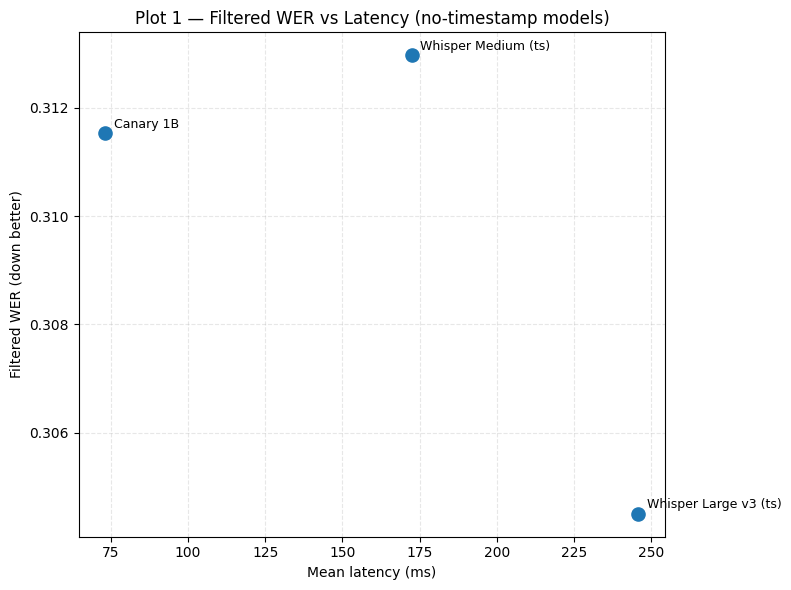

In [110]:
# =========================
# PLOT 1 — Filtered WER vs Latency scatter
# Accuracy-efficiency tradeoff: the ideal model sits in the bottom-left corner.
# =========================
plot_wer_vs_latency(summary, "Plot 1 — Filtered WER vs Latency (no-timestamp models)")

C:\Users\pmoreira\AppData\Local\Temp\ipykernel_19668\3252384792.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(grouped, labels=model_order, patch_artist=True,


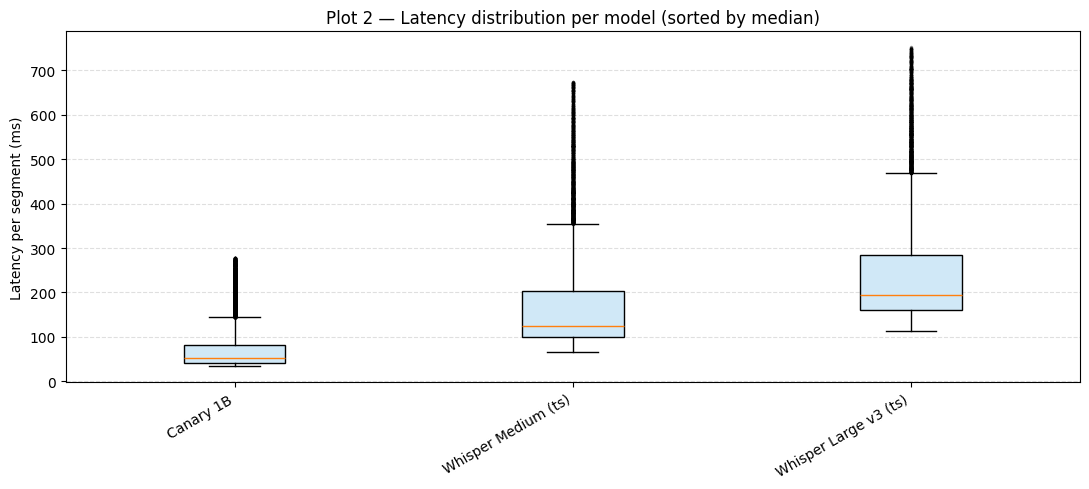

In [111]:
# =========================
# PLOT 2 — Latency distribution box plot
# Mean hides tail behaviour — for real-time use, p95 spikes matter.
# =========================
plot_latency_dist(df_latency, "Plot 2 — Latency distribution per model (sorted by median)")

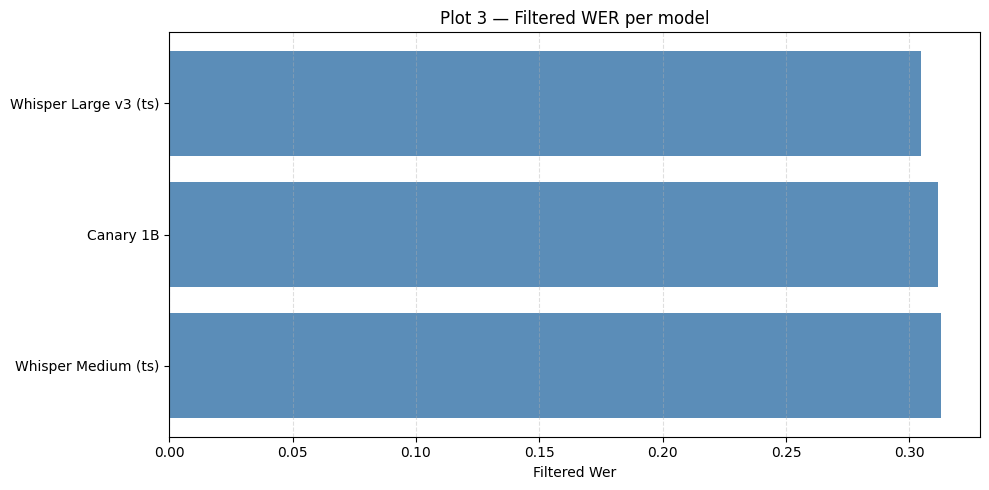

In [112]:
# =========================
# PLOT 3 — Filtered WER per model (horizontal bar)
# Quick visual ranking of models by word error rate.
# =========================
plot_metrics_bar(summary, "filtered_wer", "Plot 3 — Filtered WER per model")

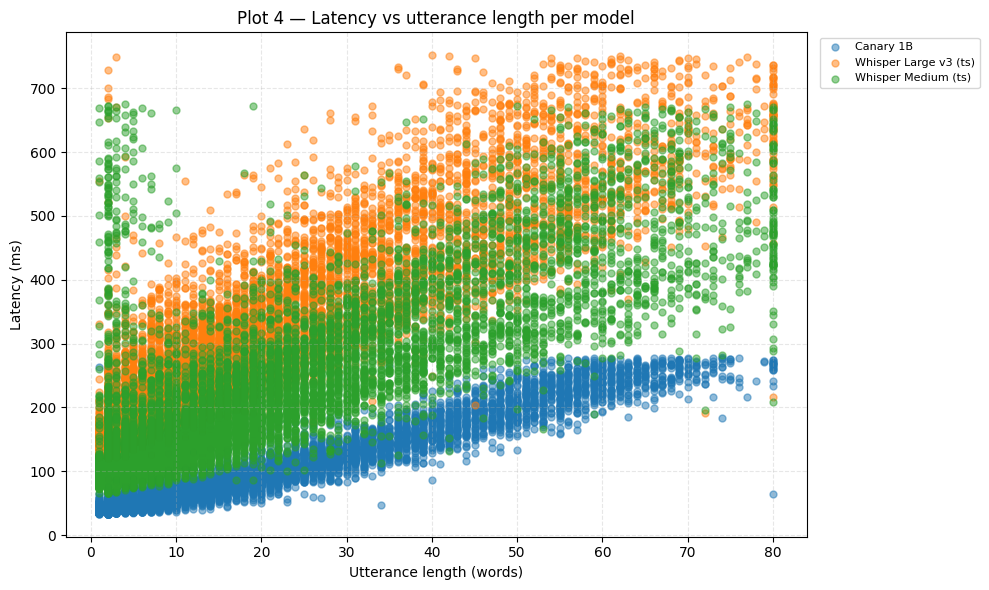

In [113]:
# =========================
# PLOT 4 — Latency vs utterance length scatter
# Checks whether any model degrades on longer segments.
# Particularly relevant for attention-based models with quadratic sequence cost.
# =========================
plot_latency_vs_length(df_latency, "Plot 4 — Latency vs utterance length per model")

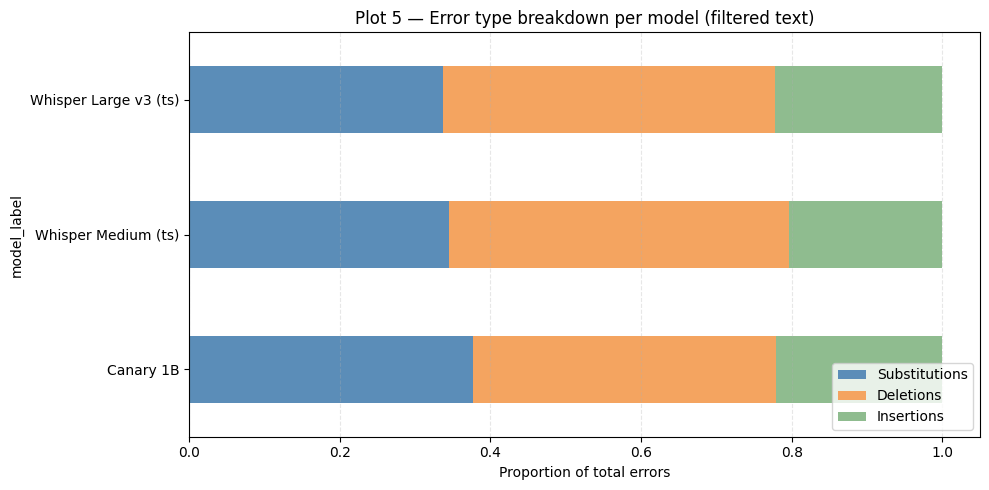

In [114]:
# =========================
# PLOT 5 — Error type breakdown (Substitutions / Deletions / Insertions)
# Different error types have different downstream consequences:
#   Substitutions → wrong entity text or label
#   Deletions     → missed entities (false negatives in NER)
#   Insertions    → hallucinated words that may trigger false positives in NER
# =========================
plot_error_breakdown(df_eval, "Plot 5 — Error type breakdown per model (filtered text)")

# Sensitivity Analysis

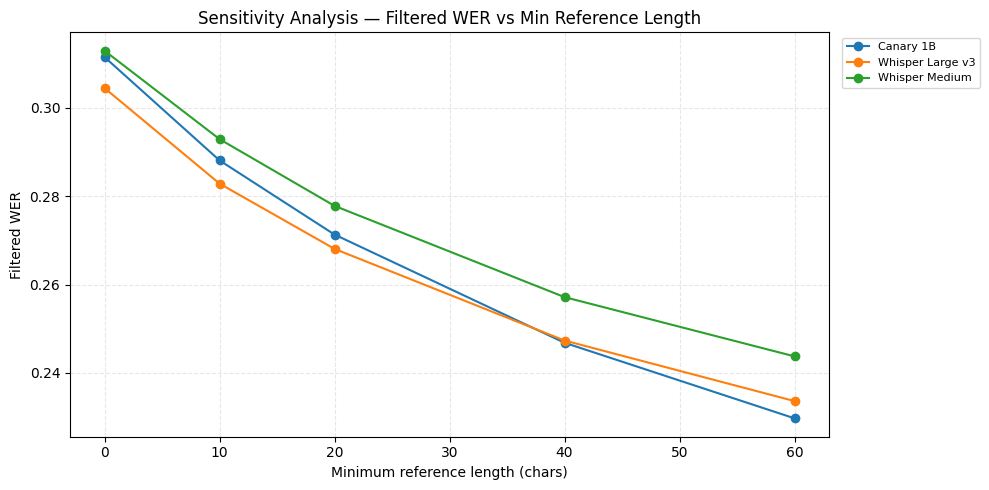

min_chars,0.0,10.0,20.0,40.0,60.0
model_clean,,,,,
Canary 1B,0.3115,0.2881,0.2713,0.2468,0.2297
Whisper Large v3,0.3045,0.2829,0.2681,0.2473,0.2336
Whisper Medium,0.3130,0.2929,0.2778,0.2572,0.2437


In [115]:
# =========================
# WER vs MIN_REF_CHARS THRESHOLD SWEEP
# Shows how metrics shift as we exclude shorter segments.
# Short utterances inflate WER because single-word errors dominate.
# The right threshold depends on the downstream use case.
# =========================
thresholds = [0, 10, 20, 40, 60]
rows = []

for min_chars in thresholds:
    df_thresh = df_raw.copy()
    df_thresh["ref_num_chars"] = df_thresh["reference_text"].astype(str).str.len()
    if min_chars > 0:
        df_thresh = df_thresh[df_thresh["ref_num_chars"] >= min_chars].copy()

    n_variants = df_thresh["model_variant"].nunique()
    common_segs = (
        df_thresh.groupby("segment_id")["model_variant"]
                 .nunique()
                 .loc[lambda x: x == n_variants]
                 .index
    )
    df_thresh = df_thresh[df_thresh["segment_id"].isin(common_segs)].copy()

    df_thresh["ref_filtered"] = df_thresh["reference_text"].apply(filter_fillers)
    df_thresh["hyp_filtered"] = df_thresh["asr_text"].apply(filter_fillers)
    df_thresh = df_thresh[
        ~((df_thresh["ref_filtered"] == "") & (df_thresh["hyp_filtered"] == ""))
    ].copy()

    temp = (
        df_thresh.groupby(["model", "timestamp_mode", "model_variant"])
        .apply(lambda g: pd.Series({
            "filtered_wer": wer(g["ref_filtered"].tolist(), g["hyp_filtered"].tolist()),
            "num_segments": len(g),
            "min_chars":    min_chars,
        }))
        .reset_index()
    )
    rows.append(temp)

threshold_df = pd.concat(rows, ignore_index=True)
threshold_df["model_clean"] = threshold_df["model"].map(CLEAN_NAMES).fillna(threshold_df["model"])

# Line plot: WER vs threshold, one line per model (no-timestamp only)
fig, ax = plt.subplots(figsize=(10, 5))
for model_clean, group in (
    threshold_df
    .groupby("model_clean")
):
    ax.plot(group["min_chars"], group["filtered_wer"], marker="o", label=model_clean)

ax.set_xlabel("Minimum reference length (chars)")
ax.set_ylabel("Filtered WER")
ax.set_title("Sensitivity Analysis — Filtered WER vs Min Reference Length")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# Pivot table summary
threshold_df.pivot(
    index="model_clean", columns="min_chars", values="filtered_wer"
).round(4)

# Misc


In [116]:
# =========================
# INVESTIGATION 1 — Normalisation impact
#
# AMI reference transcripts use a non-standard format that inflates WER:
#   - Spaced punctuation: "No , we can't afford both ."  (45% of refs)
#   - Underscore-encoded letter spelling: "B_R_E_"  (4% of refs)
#   - Captured disfluencies: "this this is just this is just"  (23% have uh/um alone)
#
# Models produce clean, attached-punctuation output with no disfluencies.
# This table shows how much each normalisation step moves the needle.
# =========================
import re

_FILLER = {'uh','um','mm','hmm','hm','mhm','mmhm','mmhmm','ah','eh','er','erm','huh','uhu','uhuh','mmm'}

def _norm_lower(t):
    return str(t).lower()

def _norm_punct(t):
    t = _norm_lower(t)
    t = re.sub(r"[^\w\s']", ' ', t)   # removes spaced AND attached punctuation
    return re.sub(r'\s+', ' ', t).strip()

def _norm_underscore(t):
    # AMI letter spelling: B_R_E_ -> B R E
    t = _norm_punct(t)
    return re.sub(r'_', ' ', t)

def _norm_fillers(t):
    t = _norm_underscore(t)
    return ' '.join(w for w in t.split() if w not in _FILLER)

norm_steps = [
    ("Raw (no normalisation)",              lambda r, h: (r, h)),
    ("Lowercase only",                      lambda r, h: (_norm_lower(r), _norm_lower(h))),
    ("+ Remove punctuation",               lambda r, h: (_norm_punct(r), _norm_punct(h))),
    ("+ Fix underscores (B_R_E_ -> B R E)", lambda r, h: (_norm_underscore(r), _norm_underscore(h))),
    ("+ Strip filler words",               lambda r, h: (_norm_fillers(r), _norm_fillers(h))),
]

def _model_label(mv):
    model, ts = mv.split(" | ")
    name = CLEAN_NAMES.get(model, model)
    return name + (" (ts)" if ts == "timestamps" else "")

norm_rows = []
for model_variant, grp in df_eval.groupby("model_variant"):
    for label, fn in norm_steps:
        pairs = [fn(r, h) for r, h in zip(grp["ref_raw"], grp["hyp_raw"]) if r.strip()]
        rs, hs = zip(*pairs)
        w = process_words(list(rs), list(hs))
        norm_rows.append({
            "model_clean":        _model_label(model_variant),
            "Normalisation step": label,
            "WER":                round(w.wer, 4),
        })

norm_df = pd.DataFrame(norm_rows)
pivot = norm_df.pivot(index="Normalisation step", columns="model_clean", values="WER")
step_order = [s for s, _ in norm_steps]
display(pivot.reindex(step_order).round(4))

model_clean,Canary 1B,Whisper Large v3 (ts),Whisper Medium (ts)
Normalisation step,,,
Raw (no normalisation),0.5381,0.5340,0.5388
Lowercase only,0.5167,0.5096,0.5144
+ Remove punctuation,0.3307,0.3235,0.3316
+ Fix underscores (B_R_E_ -> B R E),0.3343,0.3268,0.3349
+ Strip filler words,0.3115,0.3045,0.3130


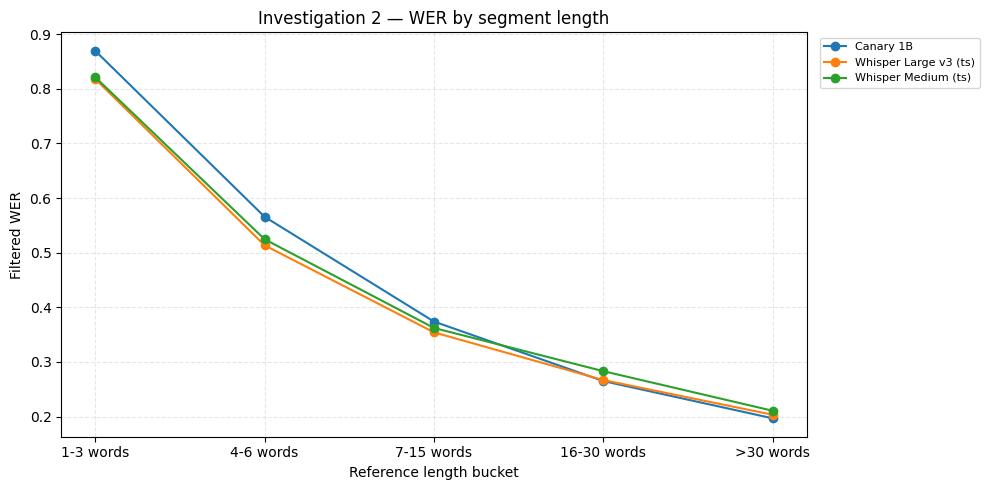


Segments per length bucket:


,count
bucket,
1-3,7300
4-6,2607
7-15,3796
16-30,2253
>30,2147


In [117]:
# =========================
# INVESTIGATION 2 — WER by segment length
#
# Short segments dominate the dataset (~40% are 1–3 words) and have
# drastically higher WER — a single wrong word is 50–100% error.
# Whisper in particular tends to hallucinate context for very short segments,
# producing several words where the reference has one.
# =========================
buckets = [
    (1,  3,  "1-3 words"),
    (4,  6,  "4-6 words"),
    (7,  15, "7-15 words"),
    (16, 30, "16-30 words"),
    (31, 999,">30 words"),
]

def _model_label(model, ts_mode):
    name = CLEAN_NAMES.get(model, model)
    return name + (" (ts)" if ts_mode == "timestamps" else "")

length_rows = []
for lo, hi, label in buckets:
    mask = df_eval["ref_filtered"].apply(lambda t: lo <= len(t.split()) <= hi)
    subset = df_eval[mask]
    if subset.empty:
        continue
    for (model, ts_mode), grp in subset.groupby(["model", "timestamp_mode"]):
        refs = grp["ref_filtered"].tolist()
        hyps = grp["hyp_filtered"].tolist()
        if not refs:
            continue
        w = process_words(refs, hyps)
        length_rows.append({
            "Length bucket": label,
            "model_clean":   _model_label(model, ts_mode),
            "Segments":      len(grp),
            "WER":           round(w.wer, 4),
        })

length_df = pd.DataFrame(length_rows)

fig, ax = plt.subplots(figsize=(10, 5))
for model_clean, grp in length_df.groupby("model_clean"):
    ax.plot(grp["Length bucket"], grp["WER"], marker="o", label=model_clean)
ax.set_xlabel("Reference length bucket")
ax.set_ylabel("Filtered WER")
ax.set_title("Investigation 2 — WER by segment length")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table: segment count per bucket (model-agnostic, deduplicated)
bucket_counts = (
    df_eval.drop_duplicates("segment_id")
    .assign(bucket=lambda d: pd.cut(
        d["ref_filtered"].apply(lambda t: len(t.split())),
        bins=[0,3,6,15,30,999],
        labels=["1-3","4-6","7-15","16-30",">30"]
    ))
    ["bucket"].value_counts().sort_index()
)
print("\nSegments per length bucket:")
display(bucket_counts.rename("count").to_frame())

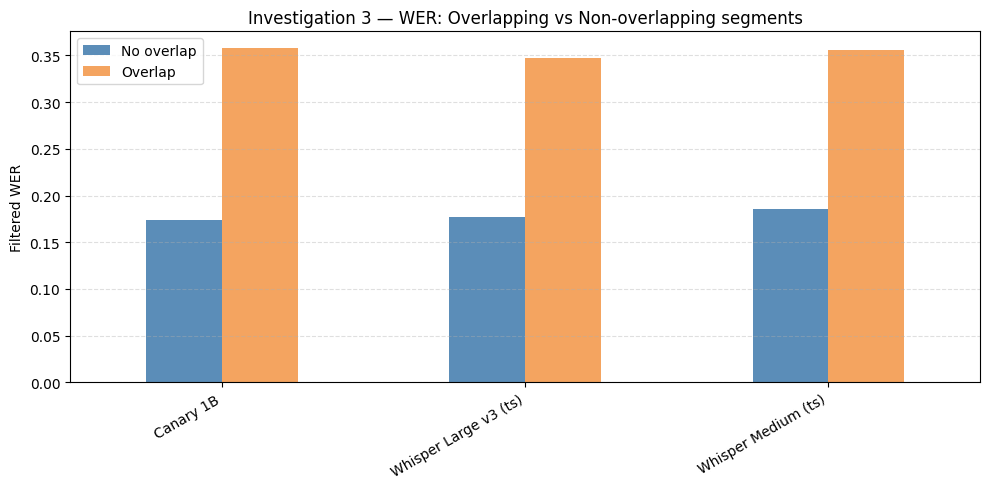


Segment counts:


Condition,No overlap (n),Overlap (n)
model_clean,,
Canary 1B,4704,14665
Whisper Large v3 (ts),4654,14394
Whisper Medium (ts),4625,14203


In [118]:
# =========================
# INVESTIGATION 3 — Overlap vs non-overlapping speech
#
# AMI segments flagged as overlapping (two speakers talking simultaneously)
# account for ~70% of the dataset. Models receive a single mixed-audio channel
# and must transcribe the dominant speaker, making these segments much harder.
# Non-overlapping WER gives a cleaner ceiling estimate of model capability.
# =========================
def _model_label(model, ts_mode):
    name = CLEAN_NAMES.get(model, model)
    return name + (" (ts)" if ts_mode == "timestamps" else "")

overlap_rows = []
for (model, ts_mode), grp in df_eval.groupby(["model", "timestamp_mode"]):
    for overlap_flag, label in [(True, "Overlap"), (False, "No overlap")]:
        subset = grp[grp["overlap"] == overlap_flag]
        if subset.empty:
            continue
        refs = subset["ref_filtered"].tolist()
        hyps = subset["hyp_filtered"].tolist()
        w = process_words(refs, hyps)
        overlap_rows.append({
            "model_clean": _model_label(model, ts_mode),
            "Condition":   label,
            "Segments":    len(subset),
            "WER":         round(w.wer, 4),
        })

overlap_df = pd.DataFrame(overlap_rows)

pivot = overlap_df.pivot(index="model_clean", columns="Condition", values="WER").sort_values("No overlap")
ax = pivot.plot(kind="bar", figsize=(10, 5), color=["#5b8db8", "#f4a460"])
ax.set_ylabel("Filtered WER")
ax.set_title("Investigation 3 — WER: Overlapping vs Non-overlapping segments")
ax.set_xlabel("")
ax.legend(title="")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("\nSegment counts:")
display(
    overlap_df.pivot(index="model_clean", columns="Condition", values="Segments")
              .rename(columns={"No overlap": "No overlap (n)", "Overlap": "Overlap (n)"})
)